# EEG Детекција на Алцхајмер — EEGNet vs LaBraM+LoRA vs BIOT

**Датасет:** ADFTD — OpenNeuro ds004504 (88 субјекти: 36 AD - Alzheimer Disease , 23 FTD - Frontotemporal Dementia, 29 CN - Cognitively Normal)  
**Поделба:** Subject-level split (без data leakage)  
**Модели:** EEGNet, LaBraM+LoRA, BIOT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
SAVE_DIR = '/content/drive/MyDrive/ISOK/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')


Save directory: /content/drive/MyDrive/ISOK/


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
!pip install mne openneuro-py scikit-learn matplotlib seaborn braindecode huggingface_hub scipy -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.9/574.9 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 122.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
moviepy 1.0.3 re

In [ ]:
import mne
mne.set_log_level('WARNING')

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, gc, os, math, copy, pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, accuracy_score, roc_curve)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset




## 1. Преземање и предобработка на датасетот

In [ ]:
import openneuro as on
import os

In [ ]:
DATA_DIR = '/content/adftd'

if not os.path.exists(DATA_DIR):
    print('Датасетот се превзема.')
    on.download(
        dataset='ds004504',
        target_dir=DATA_DIR
    )
    print('Готово')
else:
    print('Датасетот веќе постои, прескокнуваме преземање.')


entries = sorted(os.listdir(DATA_DIR))
sub_dirs = [e for e in entries if e.startswith('sub-')]
print(f'Вкупно субјекти: {len(sub_dirs)}')
print(f'Прв субјект: {sub_dirs[0]}')

Датасетот веќе постои, прескокнуваме преземање.
Вкупно субјекти: 88
Прв субјект: sub-001


In [ ]:
participants_path = os.path.join(DATA_DIR, 'participants.tsv')
df = pd.read_csv(participants_path, sep='\t')
print('Колони:', df.columns.tolist())
print()
print('Дистрибуција по групи:')
print(df['Group'].value_counts())
print()
# A = Alzheimer, F = FTD, C = Control
print(df.head(10))

Колони: ['participant_id', 'Gender', 'Age', 'Group', 'MMSE']

Дистрибуција по групи:
Group
A    36
C    29
F    23
Name: count, dtype: int64

  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22
5        sub-006      F   61     A    14
6        sub-007      F   79     A    20
7        sub-008      M   62     A    16
8        sub-009      F   77     A    23
9        sub-010      M   69     A    20


In [ ]:
# Проверка дали .set фајловите се навистина преземени
# Важно: OpenNeuro/EEGLAB фајловите понекогаш се .set, а понекогаш .SET
set_files = sorted(
    glob.glob(os.path.join(DATA_DIR, '**', '*.set'), recursive=True) +
    glob.glob(os.path.join(DATA_DIR, '**', '*.SET'), recursive=True)
)

print(f'DATA_DIR: {DATA_DIR}')
print(f'Вкупно .set/.SET фајлови: {len(set_files)}')

if len(set_files) == 0:
    raise FileNotFoundError(
        f'Не се најдени .set/.SET фајлови во {DATA_DIR}. '
        'Провери дали download-от завршил успешно и дали Drive/runtime не е избришан.'
    )

print('Примери од најдени .set фајлови:')
for fp in set_files[:10]:
    print(' ', fp)


DATA_DIR: /content/adftd
Вкупно .set/.SET фајлови: 99
Примери од најдени .set фајлови:
  /content/adftd/derivatives/sub-069/eeg/sub-069_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-073/eeg/sub-073_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-074/eeg/sub-074_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-080/eeg/sub-080_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-082/eeg/sub-082_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-083/eeg/sub-083_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-084/eeg/sub-084_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-085/eeg/sub-085_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-086/eeg/sub-086_task-eyesclosed_eeg.set
  /content/adftd/derivatives/sub-087/eeg/sub-087_task-eyesclosed_eeg.set


In [ ]:
SFREQ     = 256    # Hz
L_FREQ    = 0.5    # Bandpass low
H_FREQ    = 45.0   # Bandpass high
EPOCH_LEN = 4.0    # секунди
OVERLAP   = 0.5    # 50% преклоп
CLASSES   = {'A': 0, 'C': 1}   # само AD vs CN

def preprocess_subject(set_path, expected_channels=19):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
    raw.pick_types(eeg=True, verbose=False)
    raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)
    if int(round(raw.info['sfreq'])) != SFREQ:
        raw.resample(SFREQ, verbose=False)
    raw.set_eeg_reference('average', verbose=False)
    epochs = mne.make_fixed_length_epochs(
        raw, duration=EPOCH_LEN,
        overlap=EPOCH_LEN * OVERLAP, verbose=False
    )
    data = epochs.get_data().astype(np.float32)

    # За стабилна форма (epochs, 19, 1024): ако има повеќе канали, земи први 19;
    # ако има помалку, пријави јасна грешка.
    if data.shape[1] < expected_channels:
        raise ValueError(f'Субјектот има {data.shape[1]} EEG канали, а се очекуваат {expected_channels}.')
    data = data[:, :expected_channels, :]

    del raw, epochs
    gc.collect()
    return data

In [ ]:

df_p = df_participants[df_participants['Group'].isin(['A', 'C'])].reset_index(drop=True)
print(f'Субјекти (AD+CN): {len(df_p)}')
print(df_p['Group'].value_counts())


Субјекти (AD+CN): 65
Group
A    36
C    29
Name: count, dtype: int64


In [ ]:
import re

In [ ]:
# Проверка на epoch-бројот + листа на валидни субјекти
print('Фаза 1: Проверка на субјекти...')

# Направи мапа: participant_id -> прв пронајден .set/.SET фајл, независно од точната структура на папките.
# Важно: subject ID може да биде и во името на фајлот, пример sub-074_task-eyesclosed_eeg.set.
all_set_files = sorted(
    glob.glob(os.path.join(DATA_DIR, '**', '*.set'), recursive=True) +
    glob.glob(os.path.join(DATA_DIR, '**', '*.SET'), recursive=True)
)

set_file_by_subject = {}
for fp in all_set_files:
    norm_fp = fp.replace('\\', '/')
    m = re.search(r'(sub-\d+)', norm_fp)
    if m:
        subject_key = m.group(1)
        set_file_by_subject.setdefault(subject_key, fp)

print(f'Најдени .set/.SET фајлови: {len(all_set_files)}')
print(f'Најдени subject IDs од .set фајлови: {len(set_file_by_subject)}')
if set_file_by_subject:
    print('Први најдени subject IDs:', sorted(set_file_by_subject.keys())[:15])

file_subjects = set(set_file_by_subject.keys())

# Покажи кои групи реално имаат .set фајлови во моментално симнатиот dataset
available_df = df_participants[df_participants['participant_id'].astype(str).str.strip().isin(file_subjects)].copy()
print('\nГрупи за subjects што реално имаат .set фајл:')
if len(available_df) > 0:
    print(available_df['Group'].value_counts())
    print(available_df[['participant_id', 'Group']].head(20).to_string(index=False))
else:
    print('Ниту еден .set subject не се поклопува со participants.tsv.')

TARGET_GROUPS = ['A', 'C']
df_p_available = available_df[available_df['Group'].isin(TARGET_GROUPS)].reset_index(drop=True)

# Ако нема AD/CN фајлови, не продолжувај со празен train/test.
if len(df_p_available) == 0:
    print('\n Во моментално симнатите .set фајлови нема ниту еден A/C subject.')
    print('Subjects што имаат .set фајл, но не се A/C или не се во филтрираниот df_p:')
    if len(available_df) > 0:
        print(available_df[['participant_id', 'Group']].to_string(index=False))
    raise RuntimeError('Нема достапни AD/CN .set фајлови. Dataset-от е нецелосен или се симнати само други групи, на пример FTD.')


df_p = df_p_available.copy()
print(f'\nAD/CN subjects достапни за обработка: {len(df_p)}')
print(df_p['Group'].value_counts())

valid_subjects = []
missing_subjects = []

for _, row in df_p.iterrows():
    sub_id = str(row['participant_id']).strip()
    group  = row['Group']
    set_path = set_file_by_subject.get(sub_id)
    if set_path and os.path.exists(set_path):
        valid_subjects.append((sub_id, group, set_path))
    else:
        missing_subjects.append(sub_id)
        print(f'  НЕМА ФАЈЛ: {sub_id}')

print(f'Валидни субјекти: {len(valid_subjects)}')
print(f'Недостасуваат од достапниот AD/CN subset: {len(missing_subjects)}')

target_participants = set(df_participants[df_participants['Group'].isin(TARGET_GROUPS)]['participant_id'].astype(str).str.strip())
missing_from_download = sorted(target_participants - file_subjects)
if missing_from_download:
    print(f'\nAD/CN subjects што постојат во participants.tsv, но немаат .set фајл во DATA_DIR: {len(missing_from_download)}')
    print('Примери:', missing_from_download[:20])
    print('Ова е нормално само ако намерно работиш со делумен subset; инаку повторно преземи го dataset-от.')

if len(valid_subjects) == 0:
    print('Пример .set патеки што се најдени:')
    for fp in all_set_files[:10]:
        print(' ', fp)
    raise RuntimeError('Не е најден ниту еден валиден AD/CN субјект.')


Фаза 1: Проверка на субјекти...
Најдени .set/.SET фајлови: 166
Најдени subject IDs од .set фајлови: 88
Први најдени subject IDs: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015']

Групи за subjects што реално имаат .set фајл:
Group
A    36
C    29
F    23
Name: count, dtype: int64
participant_id Group
       sub-001     A
       sub-002     A
       sub-003     A
       sub-004     A
       sub-005     A
       sub-006     A
       sub-007     A
       sub-008     A
       sub-009     A
       sub-010     A
       sub-011     A
       sub-012     A
       sub-013     A
       sub-014     A
       sub-015     A
       sub-016     A
       sub-017     A
       sub-018     A
       sub-019     A
       sub-020     A

AD/CN subjects достапни за обработка: 65
Group
A    36
C    29
Name: count, dtype: int64
Валидни субјекти: 65
Недостасуваат од достапниот AD/CN subset: 0


In [ ]:
# Препроцесирање и зачувување на Drive со memmap (без RAM crash)
n_channels, n_times = 19, int(SFREQ * EPOCH_LEN)  # 19, 1024
X_path    = SAVE_DIR + 'X_preprocessed.npy'
y_path    = SAVE_DIR + 'y_labels.npy'
subs_path = SAVE_DIR + 'subject_ids.npy'

if os.path.exists(X_path) and os.path.exists(y_path) and os.path.exists(subs_path):
    print('Preprocessed фајлови веќе постојат — прескокнуваме.')
else:
    # Пресметка вкупен број epochs
    total_epochs = 0
    for sub_id, group, set_path in valid_subjects:
        try:
            raw = mne.io.read_raw_eeglab(set_path, preload=False, verbose=False)
            duration = raw.times[-1]
            n_ep = max(0, int((duration - EPOCH_LEN) / (EPOCH_LEN*(1-OVERLAP))) + 1)
            total_epochs += n_ep
            del raw
        except Exception as e:
            print(f'  Не можам да проценам epochs за {sub_id}: {e}')

    if total_epochs == 0:
        raise RuntimeError('Проценетиот број на epochs е 0. Провери ги .set фајловите и DATA_DIR.')

    print(f'Проценет број epochs: {total_epochs}')

    X_tmp_path = SAVE_DIR + 'X_preprocessed_tmp.npy'
    X_mm = np.lib.format.open_memmap(
        X_tmp_path, mode='w+', dtype=np.float32,
        shape=(total_epochs, n_channels, n_times)
    )
    y_list, subs_list = [], []
    cursor = 0

    print('Фаза 2: Препроцесинг...')
    for sub_id, group, set_path in valid_subjects:
        try:
            data  = preprocess_subject(set_path, expected_channels=n_channels)
            n     = len(data)
            label = CLASSES[group]
            X_mm[cursor:cursor+n] = data
            X_mm.flush()
            y_list.extend([label] * n)
            subs_list.extend([sub_id] * n)
            cursor += n
            print(f'  OK {sub_id} ({group}): {n} epochs | Вкупно: {cursor}')
            del data; gc.collect()
        except Exception as e:
            print(f'  ГРЕШКА {sub_id}: {e}')

    if cursor == 0:
        raise RuntimeError('Ниту еден субјект не е успешно препроцесиран.')

    # Точна форма без празни редови ако имало пропаднати субјекти/погрешна проценка
    X_trim = np.lib.format.open_memmap(
        X_path, mode='w+', dtype=np.float32,
        shape=(cursor, n_channels, n_times)
    )
    X_trim[:] = X_mm[:cursor]
    X_trim.flush()

    np.save(y_path,    np.array(y_list[:cursor]))
    np.save(subs_path, np.array(subs_list[:cursor]))

    del X_mm, X_trim
    if os.path.exists(X_tmp_path):
        os.remove(X_tmp_path)

    print(f'Зачувано: X({cursor}, {n_channels}, {n_times}), y({cursor}), subs({cursor})')


Preprocessed фајлови веќе постојат — прескокнуваме.


In [ ]:
X    = np.load(SAVE_DIR + 'X_preprocessed.npy', mmap_mode='r')
y    = np.load(SAVE_DIR + 'y_labels.npy')
subs = np.load(SAVE_DIR + 'subject_ids.npy')

if not (len(X) == len(y) == len(subs)):
    raise ValueError(f'Несовпаѓање во должини: X={len(X)}, y={len(y)}, subs={len(subs)}')

print(f'X:    {X.shape}')
print(f'y:    {y.shape}')
print(f'subs: {subs.shape}')
print(f'AD: {(y==0).sum()}, CN: {(y==1).sum()}')
print(f'Уникатни субјекти со epochs: {len(np.unique(subs))}')


X:    (26150, 19, 1024)
y:    (26150,)
subs: (26150,)
AD: 14514, CN: 11636
Уникатни субјекти со epochs: 64


## 2. Subject-level Train/Test Split

> **Важно:** Поделбата е на ниво на **субјект** — сите epochs од еден субјект одат само во train ИЛИ само во test. Ова спречува data leakage.

In [ ]:
# Поделба на субјекти 80/20, стратифицирано по група

subject_labels = (
    pd.DataFrame({
        'participant_id': list(subs),
        'label': list(y)
    })
    .drop_duplicates('participant_id')
    .sort_values('participant_id')
    .reset_index(drop=True)
)

subjects = subject_labels['participant_id'].astype(str).to_numpy()
groups = subject_labels['label'].astype(int).to_numpy()

print('Вкупно субјекти за split:', len(subjects))
print('Групи пред split:', pd.Series(groups).map({0: 'AD', 1: 'CN'}).value_counts().to_dict())

sub_train, sub_test = train_test_split(
    subjects,
    test_size=0.2,
    stratify=groups,
    random_state=42
)

train_mask = np.isin(subjects, sub_train)
test_mask = np.isin(subjects, sub_test)

print(f'Train субјекти: {len(sub_train)}')
print(f'Test субјекти:  {len(sub_test)}')

print(
    'Train групи:',
    pd.Series(groups[train_mask]).map({0: 'AD', 1: 'CN'}).value_counts().to_dict()
)

print(
    'Test групи: ',
    pd.Series(groups[test_mask]).map({0: 'AD', 1: 'CN'}).value_counts().to_dict()
)

print(f'Test: {sorted(sub_test.tolist())}')

Вкупно субјекти за split: 64
Групи пред split: {'AD': 36, 'CN': 28}
Train субјекти: 51
Test субјекти:  13
Train групи: {'AD': 29, 'CN': 22}
Test групи:  {'AD': 7, 'CN': 6}
Test: [np.str_('sub-007'), np.str_('sub-008'), np.str_('sub-015'), np.str_('sub-019'), np.str_('sub-021'), np.str_('sub-026'), np.str_('sub-029'), np.str_('sub-039'), np.str_('sub-048'), np.str_('sub-051'), np.str_('sub-055'), np.str_('sub-056'), np.str_('sub-059')]


In [ ]:
idx_train = np.where(np.isin(subs, sub_train))[0]
idx_test  = np.where(np.isin(subs, sub_test))[0]

print(f'Train epochs: {len(idx_train)} | AD: {(y[idx_train]==0).sum()} | CN: {(y[idx_train]==1).sum()}')
print(f'Test epochs:  {len(idx_test)}  | AD: {(y[idx_test]==0).sum()}  | CN: {(y[idx_test]==1).sum()}')

# Проверка дека нема преклоп
overlap = set(subs[idx_train]) & set(subs[idx_test])
print(f'Преклоп на субјекти: {len(overlap)}')


Train epochs: 20655 | AD: 11556 | CN: 9099
Test epochs:  5495  | AD: 2958  | CN: 2537
Преклоп на субјекти: 0


In [ ]:
y = np.asarray(y, dtype=np.int64)
subs = np.asarray(subs).astype(str)
sub_train = np.asarray(sub_train).astype(str)
sub_test = np.asarray(sub_test).astype(str)
idx_train = np.asarray(idx_train, dtype=np.int64)
idx_test = np.asarray(idx_test, dtype=np.int64)

train_subject_labels = subject_labels[
    subject_labels['participant_id'].astype(str).isin(sub_train)
].copy()

train_subject_labels['participant_id'] = train_subject_labels['participant_id'].astype(str)
train_subject_labels['label'] = train_subject_labels['label'].astype(int)

print('Train subject labels:')
print(train_subject_labels['label'].map({0: 'AD', 1: 'CN'}).value_counts().to_dict())

Train subject labels:
{'AD': 29, 'CN': 22}


In [ ]:
train_subject_labels = subject_labels[subject_labels['participant_id'].isin(sub_train)].copy()

def get_labeled_epoch_indices(frac, random_state=42):
    """
    Избира frac од train субјектите, стратифицирано по класа,
    и ги враќа само train epochs од избраните субјекти.
    """

    if frac >= 1.0:
        chosen_subjects = sub_train.copy()
    else:
        n_subjects = max(2, int(round(len(sub_train) * frac)))
        n_subjects = min(n_subjects, len(sub_train))

        chosen_subjects, _ = train_test_split(
            train_subject_labels['participant_id'].to_numpy(),
            train_size=n_subjects,
            stratify=train_subject_labels['label'].to_numpy(),
            random_state=random_state
        )

    chosen_subjects = np.asarray(chosen_subjects).astype(str)

    train_mask = np.isin(subs[idx_train], chosen_subjects)
    idx_sub = idx_train[train_mask]

    idx_sub = np.asarray(idx_sub, dtype=np.int64)

    return idx_sub, chosen_subjects


In [ ]:
print('X dtype:', X.dtype)
print('X shape:', X.shape)

train_sample = X[idx_train[:500]]
print('Train sample min/max:', train_sample.min(), train_sample.max())
print('Train sample mean:', train_sample.mean())
print('Train sample std:', train_sample.std())

print('Scientific notation:')
print('min:', f'{train_sample.min():.8e}')
print('max:', f'{train_sample.max():.8e}')
print('mean:', f'{train_sample.mean():.8e}')
print('std:', f'{train_sample.std():.8e}')

X dtype: float32
X shape: (26150, 19, 1024)
Train sample min/max: -0.00050832576 0.000675199
Train sample mean: 1.1608024e-15
Train sample std: 1.1044092e-05
Scientific notation:
min: -5.08325757e-04
max: 6.75198971e-04
mean: 1.16080243e-15
std: 1.10440924e-05


In [ ]:
print('Пресметување на mean/std од train сет...')

idx_train = np.asarray(idx_train, dtype=np.int64)

n_channels = X.shape[1]
ch_sum  = np.zeros(n_channels, dtype=np.float64)
ch_sum2 = np.zeros(n_channels, dtype=np.float64)
n_total = 0
CHUNK = 500

for i in range(0, len(idx_train), CHUNK):
    batch_idx = idx_train[i:i+CHUNK]
    batch = np.asarray(X[batch_idx], dtype=np.float64)

    ch_sum  += batch.sum(axis=(0, 2))
    ch_sum2 += (batch ** 2).sum(axis=(0, 2))
    n_total += batch.shape[0] * batch.shape[2]

channel_mean = ch_sum / n_total
channel_var = ch_sum2 / n_total - channel_mean ** 2

# Заштита од многу мали негативни вредности поради floating-point rounding
channel_var = np.maximum(channel_var, 0)

channel_std = np.sqrt(channel_var)

# Ако некој канал има std = 0, стави 1 за да нема делење со нула
channel_std_safe = np.where(channel_std < 1e-12, 1.0, channel_std)

X_mean = channel_mean.astype(np.float32).reshape(1, n_channels, 1)
X_std  = channel_std_safe.astype(np.float32).reshape(1, n_channels, 1)

n_times   = X.shape[2]
n_classes = 2

print(f'Mean range: [{X_mean.min():.8e}, {X_mean.max():.8e}]')
print(f'Std range:  [{X_std.min():.8e}, {X_std.max():.8e}]')

print('Број на канали со речиси нула std:', np.sum(channel_std < 1e-12))

Пресметување на mean/std од train сет...
Mean range: [-6.84795387e-10, 9.19307575e-10]
Std range:  [6.93642005e-06, 4.00813551e-05]
Број на канали со речиси нула std: 0


In [ ]:
print('Нормализација на X...')

X_norm = np.empty_like(X, dtype=np.float32)
CHUNK = 500

for i in range(0, len(X), CHUNK):
    batch = X[i:i+CHUNK].astype(np.float32)
    X_norm[i:i+CHUNK] = (batch - X_mean) / X_std

print('Готово.')
print('X_norm shape:', X_norm.shape)
print('X_norm dtype:', X_norm.dtype)

train_sample_norm = X_norm[idx_train[:500]]

print('Train normalized sample mean:', train_sample_norm.mean())
print('Train normalized sample std:', train_sample_norm.std())
print('Train normalized min/max:', train_sample_norm.min(), train_sample_norm.max())

Нормализација на X...
Готово.
X_norm shape: (26150, 19, 1024)
X_norm dtype: float32
Train normalized sample mean: -3.2355485e-05
Train normalized sample std: 0.9940565
Train normalized min/max: -39.50602 52.47509


In [ ]:
X_norm = np.clip(X_norm, -10, 10)

print('After clipping:')
train_sample_norm = X_norm[idx_train[:500]]
print('Train normalized sample mean:', train_sample_norm.mean())
print('Train normalized sample std:', train_sample_norm.std())
print('Train normalized min/max:', train_sample_norm.min(), train_sample_norm.max())

After clipping:
Train normalized sample mean: -0.0006538143
Train normalized sample std: 0.92369705
Train normalized min/max: -10.0 10.0


In [ ]:
print(idx_train.shape)
print(idx_train.min(), idx_train.max())
print(np.unique(idx_train[:5]))

(20655,)
0 26149
[0 1 2 3 4]


## 3. Dataset класа и заеднички функции за обука

In [ ]:
class EEGDataset(Dataset):
    """Нормализација се врши on-the-fly, X е memmap — не се вчитува во RAM."""
    def __init__(self, X, y, mean, std):
        self.X    = X
        self.y    = torch.LongTensor(y)
        self.mean = torch.FloatTensor(mean)  # (1, 19, 1)
        self.std  = torch.FloatTensor(std)   # (1, 19, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.X[idx].copy()).unsqueeze(0)  # (1, 19, 1024)
        x = (x - self.mean) / self.std
        return x, self.y[idx]

dataset     = EEGDataset(X, y, X_mean, X_std)
test_set    = Subset(dataset, idx_test)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

print(f'Вкупно epochs во dataset: {len(dataset)}')
print(f'Test set: {len(test_set)} epochs')


Вкупно epochs во dataset: 26150
Test set: 5495 epochs


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total


In [ ]:
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out   = model(Xb)
            loss  = criterion(out, yb)
            probs = torch.softmax(out, dim=1)[:, 1]
            preds = out.argmax(1)
            total_loss += loss.item() * len(yb)
            correct    += (preds == yb).sum().item()
            total      += len(yb)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    if total == 0:
        return 0.0, 0.0, 0.5, [], []
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.5
    return total_loss/total, correct/total, auc, all_preds, all_labels


In [ ]:
def eval_epoch_safe(model, loader, criterion, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            if torch.isnan(logits).any():
                continue
            loss  = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())
            total_loss += loss.item()
    if len(all_labels) == 0:
        return total_loss, 0.0, 0.5, [], []
    all_probs  = np.where(np.isnan(all_probs), 0.5, np.array(all_probs))
    all_labels = np.array(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.5
    return total_loss / max(len(loader), 1), acc, auc, all_preds, all_labels


In [ ]:
def train_model(model, train_loader, test_loader, n_epochs=50,
                lr=1e-3, device=device, save_path=None, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    history   = {'train_loss':[], 'train_acc':[],
                 'val_loss':[], 'val_acc':[], 'val_auc':[]}
    best_auc  = 0
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc, _, _ = eval_epoch(model, test_loader, criterion, device)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        if vl_auc > best_auc:
            best_auc = vl_auc
            if save_path:
                torch.save(model.state_dict(), save_path)
        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f'Epoch {epoch:3d}/{n_epochs} | '
                  f'Train Acc:{tr_acc:.3f} | Val Acc:{vl_acc:.3f} AUC:{vl_auc:.3f}')
    if verbose:
        print(f'Најдобар AUC: {best_auc:.4f}')
    return history, best_auc


In [ ]:
FRACTIONS = [0.10, 0.25, 0.50, 1.00]
N_EPOCHS  = 50


## 4. Модел 1 — EEGNet

Компактна CNN за EEG -> Temporal conv → Depthwise spatial conv → Separable conv.

In [ ]:
class EEGNet(nn.Module):
    """
    EEGNet:
    Input: (batch, 1, n_channels, n_times)
    """
    def __init__(self, n_classes=2, n_channels=19, n_times=1024,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)), nn.Dropout(dropout)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(F1*D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)), nn.Dropout(dropout)
        )
        self._flat_dim = self._get_flat_dim(n_channels, n_times, F1, D, F2)
        self.classifier = nn.Linear(self._flat_dim, n_classes)

    def _get_flat_dim(self, n_ch, n_t, F1, D, F2):
        x = torch.zeros(1, 1, n_ch, n_t)
        return self.block3(self.block2(self.block1(x))).numel()

    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        return self.classifier(x.view(x.size(0), -1))

print(f'EEGNet параметри: {sum(p.numel() for p in EEGNet().parameters()):,}')


EEGNet параметри: 6,018


In [ ]:
eegnet_results = {}

for frac in FRACTIONS:
    print(f'\n=== EEGNet — {int(frac*100)}% labeled податоци ===')

    idx_sub, chosen_subjects = get_labeled_epoch_indices(frac, random_state=42)

    print(f'Тренинг: {len(idx_sub)} | AD: {(y[idx_sub]==0).sum()} | CN: {(y[idx_sub]==1).sum()}')

    train_loader_sub = DataLoader(
        Subset(dataset, idx_sub), batch_size=64, shuffle=True, num_workers=2
    )

    model_e   = EEGNet(n_classes=n_classes, n_channels=n_channels, n_times=n_times).to(device)
    save_path = SAVE_DIR + f'eegnet_{int(frac*100)}pct.pt'

    history, best_auc = train_model(
        model_e, train_loader_sub, test_loader,
        n_epochs=N_EPOCHS, lr=1e-3, device=device, save_path=save_path
    )

    model_e.load_state_dict(torch.load(save_path, map_location=device))
    _, final_acc, final_auc, preds, labels = eval_epoch(
        model_e, test_loader, nn.CrossEntropyLoss(), device
    )

    eegnet_results[frac] = {
        'auc': final_auc, 'acc': final_acc,
        'preds': preds, 'labels': labels,
        'history': history, 'n_train': len(idx_sub)
    }
    print(f'ФИНАЛЕН AUC: {final_auc:.4f} | Accuracy: {final_acc:.4f}')

with open(SAVE_DIR + 'eegnet_results.pkl', 'wb') as f:
    pickle.dump(eegnet_results, f)
print('\nЗачувано: eegnet_results.pkl')



=== EEGNet — 10% labeled податоци ===
Тренинг: 2052 | AD: 1263 | CN: 789
Epoch   1/50 | Train Acc:0.730 | Val Acc:0.659 AUC:0.779
Epoch  10/50 | Train Acc:0.998 | Val Acc:0.666 AUC:0.813
Epoch  20/50 | Train Acc:0.996 | Val Acc:0.604 AUC:0.679
Epoch  30/50 | Train Acc:1.000 | Val Acc:0.628 AUC:0.724
Epoch  40/50 | Train Acc:1.000 | Val Acc:0.645 AUC:0.754
Epoch  50/50 | Train Acc:1.000 | Val Acc:0.645 AUC:0.761
Најдобар AUC: 0.8399
ФИНАЛЕН AUC: 0.8399 | Accuracy: 0.7301

=== EEGNet — 25% labeled податоци ===
Тренинг: 5198 | AD: 2770 | CN: 2428
Epoch   1/50 | Train Acc:0.800 | Val Acc:0.656 AUC:0.734
Epoch  10/50 | Train Acc:0.984 | Val Acc:0.670 AUC:0.778
Epoch  20/50 | Train Acc:0.994 | Val Acc:0.678 AUC:0.787
Epoch  30/50 | Train Acc:0.994 | Val Acc:0.711 AUC:0.807
Epoch  40/50 | Train Acc:0.997 | Val Acc:0.689 AUC:0.805
Epoch  50/50 | Train Acc:0.997 | Val Acc:0.689 AUC:0.810
Најдобар AUC: 0.8320
ФИНАЛЕН AUC: 0.8320 | Accuracy: 0.7197

=== EEGNet — 50% labeled податоци ===
Тренинг:

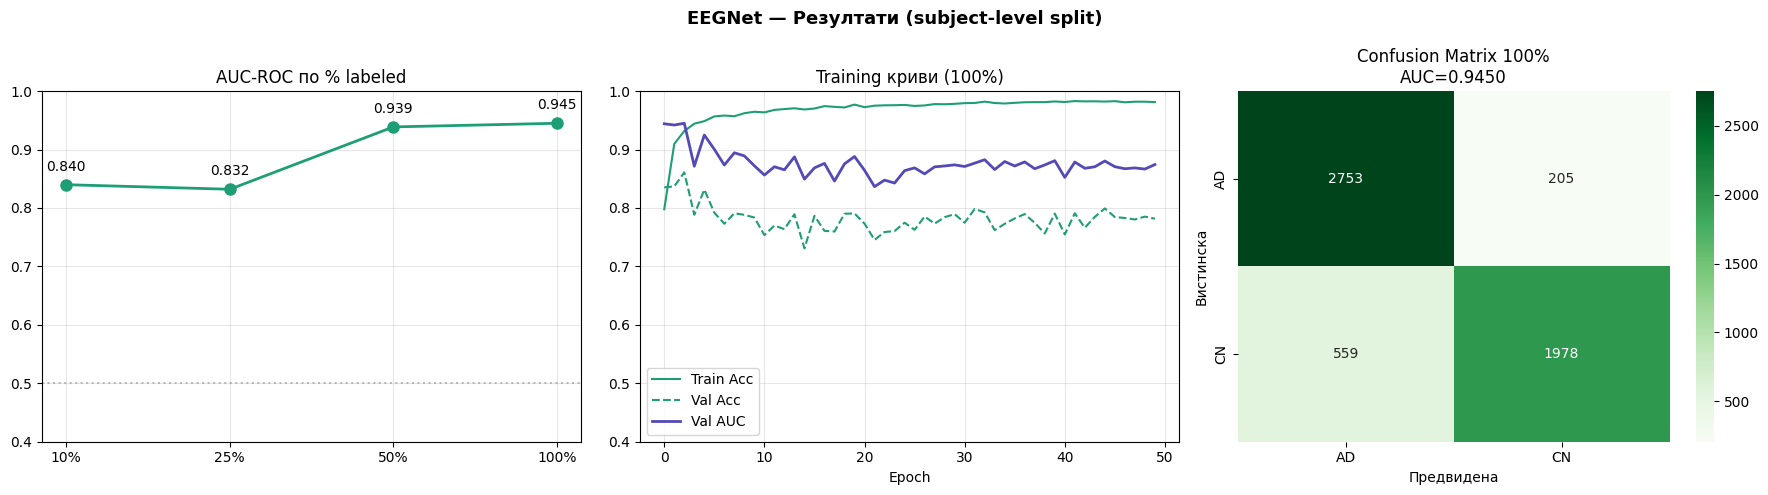

In [ ]:
fracs    = FRACTIONS
x_labels = [f'{int(f*100)}%' for f in fracs]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EEGNet — Резултати (subject-level split)', fontsize=13, fontweight='bold')


eeg_auc = [eegnet_results[f]['auc'] for f in fracs]
axes[0].plot(x_labels, eeg_auc, 'o-', color='#1D9E75', lw=2, ms=8)
for i, v in enumerate(eeg_auc):
    axes[0].annotate(f'{v:.3f}', (x_labels[i], v), textcoords='offset points', xytext=(0,10), ha='center')
axes[0].set_title('AUC-ROC по % labeled')
axes[0].set_ylim(0.4, 1.0); axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[0].grid(True, alpha=0.3)


h = eegnet_results[1.0]['history']
axes[1].plot(h['train_acc'], label='Train Acc', color='#1D9E75')
axes[1].plot(h['val_acc'],   label='Val Acc',   color='#1D9E75', linestyle='--')
axes[1].plot(h['val_auc'],   label='Val AUC',   color='#534AB7', lw=2)
axes[1].set_title('Training криви (100%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0.4, 1.0)
axes[1].legend(); axes[1].grid(True, alpha=0.3)


cm = confusion_matrix(eegnet_results[1.0]['labels'], eegnet_results[1.0]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['AD','CN'], yticklabels=['AD','CN'])
axes[2].set_title(f'Confusion Matrix 100%\nAUC={eegnet_results[1.0]["auc"]:.4f}')
axes[2].set_ylabel('Вистинска'); axes[2].set_xlabel('Предвидена')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'eegnet_results.png', dpi=150)
plt.show()


In [ ]:
print('=== Classification Report — EEGNet 100% ===')
print(classification_report(
    eegnet_results[1.0]['labels'],
    eegnet_results[1.0]['preds'],
    target_names=['AD', 'CN']
))


rows = []
for f in FRACTIONS:
    rows.append({
        'Labeled %': f'{int(f*100)}%',
        'N тренинг': eegnet_results[f]['n_train'],
        'AUC-ROC'  : f"{eegnet_results[f]['auc']:.4f}",
        'Accuracy' : f"{eegnet_results[f]['acc']:.4f}",
    })
df_eegnet = pd.DataFrame(rows)
print('\n=== EEGNet Резултати ===')
print(df_eegnet.to_string(index=False))


=== Classification Report — EEGNet 100% ===
              precision    recall  f1-score   support

          AD       0.83      0.93      0.88      2958
          CN       0.91      0.78      0.84      2537

    accuracy                           0.86      5495
   macro avg       0.87      0.86      0.86      5495
weighted avg       0.87      0.86      0.86      5495


=== EEGNet Резултати ===
Labeled %  N тренинг AUC-ROC Accuracy
      10%       2052  0.8399   0.7301
      25%       5198  0.8320   0.7197
      50%      10555  0.9388   0.8490
     100%      20655  0.9450   0.8610


## 5. Модел 2 — LaBraM + LoRA

Transformer архитектура со patch embedding и LoRA адаптери на Q и V проекциите.

In [ ]:
!pip install peft transformers -q
import peft, transformers
print(f'PEFT: {peft.__version__}  |  Transformers: {transformers.__version__}')


PEFT: 0.19.1  |  Transformers: 5.0.0


In [ ]:
class LoRALinear(nn.Module):
    """Linear слој со LoRA адаптери. W_new = W_frozen + B @ A"""
    def __init__(self, in_features, out_features, r=4, alpha=8, dropout=0.1):
        super().__init__()
        self.scale   = alpha / r
        self.linear  = nn.Linear(in_features, out_features, bias=True)
        self.lora_A  = nn.Linear(in_features, r, bias=False)
        self.lora_B  = nn.Linear(r, out_features, bias=False)
        self.dropout = nn.Dropout(dropout)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        for p in self.linear.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.linear(x) + self.lora_B(self.lora_A(self.dropout(x))) * self.scale


In [ ]:
class EEGPatchEmbedding(nn.Module):
    """Сече EEG сигнал на patches и ги проектира во embedding простор."""
    def __init__(self, n_channels=19, n_times=1024, patch_size=64, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = n_times // patch_size
        self.n_channels = n_channels
        self.n_tokens   = self.n_patches * n_channels
        self.proj = nn.Conv1d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B, C, T = x.shape
        patches = []
        for c in range(C):
            p = self.proj(x[:, c:c+1, :])   # (B, embed_dim, n_patches)
            patches.append(p.transpose(1, 2))  # (B, n_patches, embed_dim)
        return self.norm(torch.cat(patches, dim=1))  # (B, C*n_patches, embed_dim)


In [ ]:
class TransformerBlockLoRA(nn.Module):
    def __init__(self, embed_dim=128, n_heads=4, mlp_ratio=2.0,
                 dropout=0.1, lora_r=4, lora_alpha=8):
        super().__init__()
        self.norm1    = nn.LayerNorm(embed_dim)
        self.norm2    = nn.LayerNorm(embed_dim)
        self.q_proj   = LoRALinear(embed_dim, embed_dim, r=lora_r, alpha=lora_alpha)
        self.k_proj   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj   = LoRALinear(embed_dim, embed_dim, r=lora_r, alpha=lora_alpha)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.n_heads  = n_heads
        self.head_dim = embed_dim // n_heads
        self.scale    = self.head_dim ** -0.5
        self.attn_drop = nn.Dropout(dropout)
        for p in self.k_proj.parameters():
            p.requires_grad = False
        mlp_dim = int(embed_dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout)
        )
        for p in self.ffn.parameters():
            p.requires_grad = False

    def forward(self, x):
        B, N, D = x.shape
        H, Hd   = self.n_heads, self.head_dim
        xn = self.norm1(x)
        Q  = self.q_proj(xn).view(B, N, H, Hd).transpose(1, 2)
        K  = self.k_proj(xn).view(B, N, H, Hd).transpose(1, 2)
        V  = self.v_proj(xn).view(B, N, H, Hd).transpose(1, 2)
        attn = self.attn_drop(torch.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1))
        out  = (attn @ V).transpose(1, 2).contiguous().view(B, N, D)
        x    = x + self.out_proj(out)
        return x + self.ffn(self.norm2(x))


In [ ]:
class LaBraMLoRA(nn.Module):
    """LaBraM-инспириран EEG Transformer со LoRA адаптери."""
    def __init__(self, n_channels=19, n_times=1024, n_classes=2,
                 patch_size=64, embed_dim=128, depth=4,
                 n_heads=4, dropout=0.1, lora_r=4, lora_alpha=8):
        super().__init__()
        self.patch_embed = EEGPatchEmbedding(n_channels, n_times, patch_size, embed_dim)
        n_tokens = self.patch_embed.n_tokens
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_tokens + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.blocks = nn.ModuleList([
            TransformerBlockLoRA(embed_dim, n_heads, dropout=dropout,
                                 lora_r=lora_r, lora_alpha=lora_alpha)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )
        for p in self.patch_embed.parameters():
            p.requires_grad = False
        self.pos_embed.requires_grad = False

    def forward(self, x):
        x   = x.squeeze(1)                              # (B, C, T)
        x   = self.patch_embed(x)                       # (B, n_tokens, embed_dim)
        B   = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x[:, 0]))

    def count_trainable(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

# Тест
_m = LaBraMLoRA(n_channels=n_channels, n_times=n_times)
total, trainable = _m.count_trainable()
print(f'Вкупно параметри:    {total:,}')
print(f'Се обучуваат (LoRA): {trainable:,}  ({100*trainable/total:.1f}%)')
del _m


Вкупно параметри:    593,986
Се обучуваат (LoRA): 85,058  (14.3%)


In [ ]:
labram_results = {}

for frac in FRACTIONS:
    print(f'\n=== LaBraM+LoRA — {int(frac*100)}% labeled податоци ===')

    idx_sub, chosen_subjects = get_labeled_epoch_indices(frac, random_state=42)

    print(f'Тренинг: {len(idx_sub)} | AD: {(y[idx_sub]==0).sum()} | CN: {(y[idx_sub]==1).sum()}')

    train_loader_sub = DataLoader(
        Subset(dataset, idx_sub), batch_size=32, shuffle=True, num_workers=2
    )

    model_l   = LaBraMLoRA(n_channels=n_channels, n_times=n_times, n_classes=n_classes,
                            patch_size=64, embed_dim=128, depth=4,
                            n_heads=4, lora_r=4, lora_alpha=8).to(device)
    save_path = SAVE_DIR + f'labram_{int(frac*100)}pct.pt'

    history, best_auc = train_model(
        model_l, train_loader_sub, test_loader,
        n_epochs=N_EPOCHS, lr=5e-4, device=device, save_path=save_path
    )

    model_l.load_state_dict(torch.load(save_path, map_location=device))
    _, final_acc, final_auc, preds, labels = eval_epoch(
        model_l, test_loader, nn.CrossEntropyLoss(), device
    )

    labram_results[frac] = {
        'auc': final_auc, 'acc': final_acc,
        'preds': preds, 'labels': labels,
        'history': history, 'n_train': len(idx_sub)
    }
    print(f'ФИНАЛЕН AUC: {final_auc:.4f} | Accuracy: {final_acc:.4f}')

with open(SAVE_DIR + 'labram_results.pkl', 'wb') as f:
    pickle.dump(labram_results, f)
print('\nЗачувано: labram_results.pkl')



=== LaBraM+LoRA — 10% labeled податоци ===
Тренинг: 2052 | AD: 1263 | CN: 789
Epoch   1/50 | Train Acc:0.872 | Val Acc:0.752 AUC:0.799
Epoch  10/50 | Train Acc:0.995 | Val Acc:0.761 AUC:0.845
Epoch  20/50 | Train Acc:0.998 | Val Acc:0.759 AUC:0.863
Epoch  30/50 | Train Acc:1.000 | Val Acc:0.763 AUC:0.838
Epoch  40/50 | Train Acc:1.000 | Val Acc:0.761 AUC:0.824
Epoch  50/50 | Train Acc:1.000 | Val Acc:0.760 AUC:0.822
Најдобар AUC: 0.8625
ФИНАЛЕН AUC: 0.8625 | Accuracy: 0.7587

=== LaBraM+LoRA — 25% labeled податоци ===
Тренинг: 5198 | AD: 2770 | CN: 2428
Epoch   1/50 | Train Acc:0.853 | Val Acc:0.679 AUC:0.822
Epoch  10/50 | Train Acc:0.973 | Val Acc:0.669 AUC:0.778
Epoch  20/50 | Train Acc:0.986 | Val Acc:0.675 AUC:0.751
Epoch  30/50 | Train Acc:0.995 | Val Acc:0.689 AUC:0.767
Epoch  40/50 | Train Acc:0.998 | Val Acc:0.679 AUC:0.768
Epoch  50/50 | Train Acc:0.999 | Val Acc:0.678 AUC:0.764
Најдобар AUC: 0.8222
ФИНАЛЕН AUC: 0.8222 | Accuracy: 0.6793

=== LaBraM+LoRA — 50% labeled подато

In [ ]:
fracs    = FRACTIONS
x_labels = [f'{int(f*100)}%' for f in fracs]

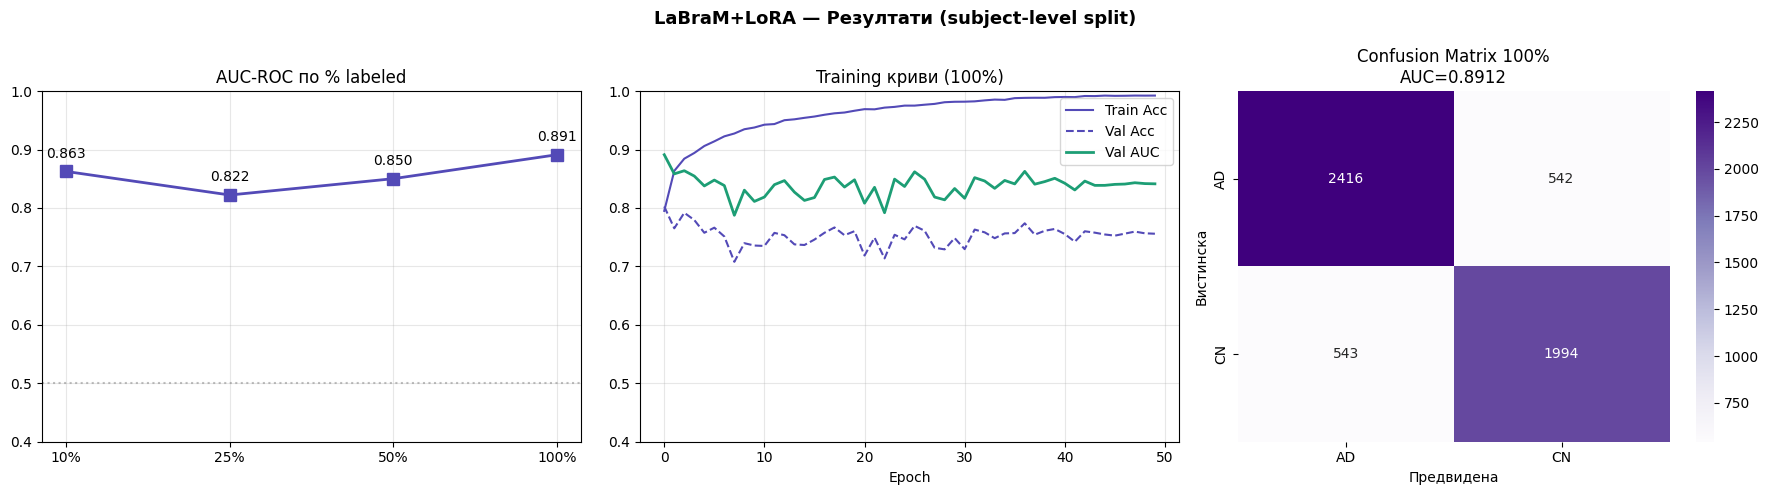

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LaBraM+LoRA — Резултати (subject-level split)', fontsize=13, fontweight='bold')

lab_auc = [labram_results[f]['auc'] for f in FRACTIONS]
axes[0].plot(x_labels, lab_auc, 's-', color='#534AB7', lw=2, ms=8)
for i, v in enumerate(lab_auc):
    axes[0].annotate(f'{v:.3f}', (x_labels[i], v), textcoords='offset points', xytext=(0,10), ha='center')
axes[0].set_title('AUC-ROC по % labeled')
axes[0].set_ylim(0.4, 1.0); axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[0].grid(True, alpha=0.3)

h = labram_results[1.0]['history']
axes[1].plot(h['train_acc'], label='Train Acc', color='#534AB7')
axes[1].plot(h['val_acc'],   label='Val Acc',   color='#534AB7', linestyle='--')
axes[1].plot(h['val_auc'],   label='Val AUC',   color='#1D9E75', lw=2)
axes[1].set_title('Training криви (100%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0.4, 1.0)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

cm = confusion_matrix(labram_results[1.0]['labels'], labram_results[1.0]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['AD','CN'], yticklabels=['AD','CN'])
axes[2].set_title(f'Confusion Matrix 100%\nAUC={labram_results[1.0]["auc"]:.4f}')
axes[2].set_ylabel('Вистинска'); axes[2].set_xlabel('Предвидена')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'labram_results.png', dpi=150)
plt.show()


In [ ]:
print('=== Classification Report — LaBraM+LoRA 100% ===')
print(classification_report(
    labram_results[1.0]['labels'],
    labram_results[1.0]['preds'],
    target_names=['AD', 'CN']
))


=== Classification Report — LaBraM+LoRA 100% ===
              precision    recall  f1-score   support

          AD       0.82      0.82      0.82      2958
          CN       0.79      0.79      0.79      2537

    accuracy                           0.80      5495
   macro avg       0.80      0.80      0.80      5495
weighted avg       0.80      0.80      0.80      5495



## 6. Модел 3 — BIOT (претрениран Foundation модел)

BIOT претрениран на PREST dataset. Fine-tuning со диференцирани learning rates.

In [ ]:
from braindecode.models import BIOT

In [ ]:
class EEGDatasetBIOT(Dataset):
    """BIOT очекува (batch, 16_channels, n_times) — земаме први 16 канали."""
    def __init__(self, X, y, mean, std):
        self.X    = X[:, :16, :]
        self.y    = torch.LongTensor(y)
        self.mean = torch.FloatTensor(mean[:, :16, :]).squeeze(0)
        self.std  = torch.FloatTensor(std[:, :16, :]).squeeze(0)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.X[idx].copy())
        return (x - self.mean) / (self.std + 1e-8), self.y[idx]

dataset_biot     = EEGDatasetBIOT(X, y, X_mean, X_std)
test_set_biot    = Subset(dataset_biot, idx_test)
test_loader_biot = DataLoader(test_set_biot, batch_size=32, shuffle=False, num_workers=2)

x_sample, _ = dataset_biot[0]
print(f'BIOT sample shape: {x_sample.shape}')  # (16, 1024)


BIOT sample shape: torch.Size([16, 1024])


In [ ]:
model_biot = BIOT.from_pretrained(
    "braindecode/biot-pretrained-prest-16chs",
    n_outputs=2,
    n_chans=16,
    n_times=1024,
    sfreq=200,
)

total     = sum(p.numel() for p in model_biot.parameters())
trainable = sum(p.numel() for p in model_biot.parameters() if p.requires_grad)
print(f'Вкупно параметри: {total:,}')
print(f'Trainable:        {trainable:,}')


config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/13.8M [00:00<?, ?B/s]

Вкупно параметри: 3,186,690
Trainable:        3,186,690


In [ ]:
xb, _ = next(iter(test_loader_biot))
with torch.no_grad():
    out = model_biot(xb)
print(f'Input:  {xb.shape}')
print(f'Output: {out.shape}')  # (32, 2)
print('Forward pass успешен!')


/usr/local/lib/python3.12/dist-packages/torch/functional.py:681: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:835.)
  return _VF.stft(  # type: ignore[attr-defined]


Input:  torch.Size([32, 16, 1024])
Output: torch.Size([32, 2])
Forward pass успешен!


In [ ]:
model_biot         = model_biot.to(device)
initial_state_biot = copy.deepcopy(model_biot.state_dict())

N_EPOCHS_BIOT = 30
biot_results  = {}


In [ ]:
for frac in FRACTIONS:
    print(f'\n{"="*50}')
    print(f'BIOT — {int(frac*100)}% labeled')
    print(f'{"="*50}')

    idx_sub, chosen_subjects = get_labeled_epoch_indices(frac, random_state=42)

    print(f'Тренинг: {len(idx_sub)} | AD: {(y[idx_sub]==0).sum()} | CN: {(y[idx_sub]==1).sum()}')

    train_loader_sub = DataLoader(
        Subset(dataset_biot, idx_sub), batch_size=32, shuffle=True, num_workers=2
    )

    # Reset на претренирани тежини
    model_biot.load_state_dict(initial_state_biot)

    # Одмрзни само float параметри
    for name, param in model_biot.named_parameters():
        param.requires_grad = (param.dtype.is_floating_point or param.dtype.is_complex)

    # Диференцирани LR: encoder мала, head поголема
    enc_params  = [p for n, p in model_biot.named_parameters()
                   if p.requires_grad and not any(k in n for k in ['head','classifier','final'])]
    head_params = [p for n, p in model_biot.named_parameters()
                   if p.requires_grad and any(k in n for k in ['head','classifier','final'])]

    if head_params:
        print(f'  Enc: {sum(p.numel() for p in enc_params):,} | Head: {sum(p.numel() for p in head_params):,}')
        optimizer = torch.optim.Adam([
            {'params': enc_params,  'lr': 1e-5, 'weight_decay': 1e-4},
            {'params': head_params, 'lr': 1e-4, 'weight_decay': 1e-5},
        ])
    else:
        print('  Head params не најдени — единствен LR 1e-4')
        optimizer = torch.optim.Adam(
            [p for p in model_biot.parameters() if p.requires_grad],
            lr=1e-4, weight_decay=1e-4
        )

    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS_BIOT)
    save_path = SAVE_DIR + f'biot_{int(frac*100)}pct.pt'
    best_auc  = 0.0
    history   = {'train_loss': [], 'val_auc': [], 'val_acc': []}

    for epoch in range(N_EPOCHS_BIOT):
        model_biot.train()
        total_loss, valid_steps = 0.0, 0

        for xb, yb in train_loader_sub:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model_biot(xb)
            if torch.isnan(logits).any():
                continue
            loss = criterion(logits, yb)
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in model_biot.parameters() if p.requires_grad and p.grad is not None],
                max_norm=1.0
            )
            optimizer.step()
            total_loss  += loss.item()
            valid_steps += 1

        scheduler.step()
        avg_loss = total_loss / max(valid_steps, 1)
        _, val_acc, val_auc, _, _ = eval_epoch_safe(model_biot, test_loader_biot, criterion, device)

        history['train_loss'].append(avg_loss)
        history['val_auc'].append(val_auc)
        history['val_acc'].append(val_acc)

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model_biot.state_dict(), save_path)

        if (epoch + 1) % 5 == 0:
            print(f'  Ep {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {val_auc:.4f} | Best: {best_auc:.4f}')

    model_biot.load_state_dict(torch.load(save_path, map_location=device))
    _, final_acc, final_auc, preds, labels = eval_epoch_safe(
        model_biot, test_loader_biot, criterion, device
    )

    biot_results[frac] = {
        'auc': final_auc, 'acc': final_acc,
        'preds': preds, 'labels': labels,
        'history': history, 'n_train': len(idx_sub)
    }
    print(f'>>> ФИНАЛЕН AUC: {final_auc:.4f} | Acc: {final_acc:.4f}')

with open(SAVE_DIR + 'biot_results.pkl', 'wb') as f:
    pickle.dump(biot_results, f)
print('\nЗачувано: biot_results.pkl')



BIOT — 10% labeled
Тренинг: 2052 | AD: 1263 | CN: 789
  Enc: 3,186,176 | Head: 514
  Ep 05 | Loss: 0.0362 | AUC: 0.8470 | Best: 0.8736
  Ep 10 | Loss: 0.0197 | AUC: 0.8929 | Best: 0.8929
  Ep 15 | Loss: 0.0130 | AUC: 0.8894 | Best: 0.8938
  Ep 20 | Loss: 0.0113 | AUC: 0.8843 | Best: 0.8938
  Ep 25 | Loss: 0.0082 | AUC: 0.8840 | Best: 0.8938
  Ep 30 | Loss: 0.0174 | AUC: 0.8843 | Best: 0.8938
>>> ФИНАЛЕН AUC: 0.8938 | Acc: 0.8246

BIOT — 25% labeled
Тренинг: 5198 | AD: 2770 | CN: 2428
  Enc: 3,186,176 | Head: 514
  Ep 05 | Loss: 0.0412 | AUC: 0.5424 | Best: 0.7351
  Ep 10 | Loss: 0.0149 | AUC: 0.5637 | Best: 0.7351
  Ep 15 | Loss: 0.0102 | AUC: 0.5569 | Best: 0.7351
  Ep 20 | Loss: 0.0074 | AUC: 0.5541 | Best: 0.7351
  Ep 25 | Loss: 0.0047 | AUC: 0.5500 | Best: 0.7351
  Ep 30 | Loss: 0.0042 | AUC: 0.5486 | Best: 0.7351
>>> ФИНАЛЕН AUC: 0.7351 | Acc: 0.6508

BIOT — 50% labeled
Тренинг: 10555 | AD: 6082 | CN: 4473
  Enc: 3,186,176 | Head: 514
  Ep 05 | Loss: 0.0579 | AUC: 0.5293 | Best: 

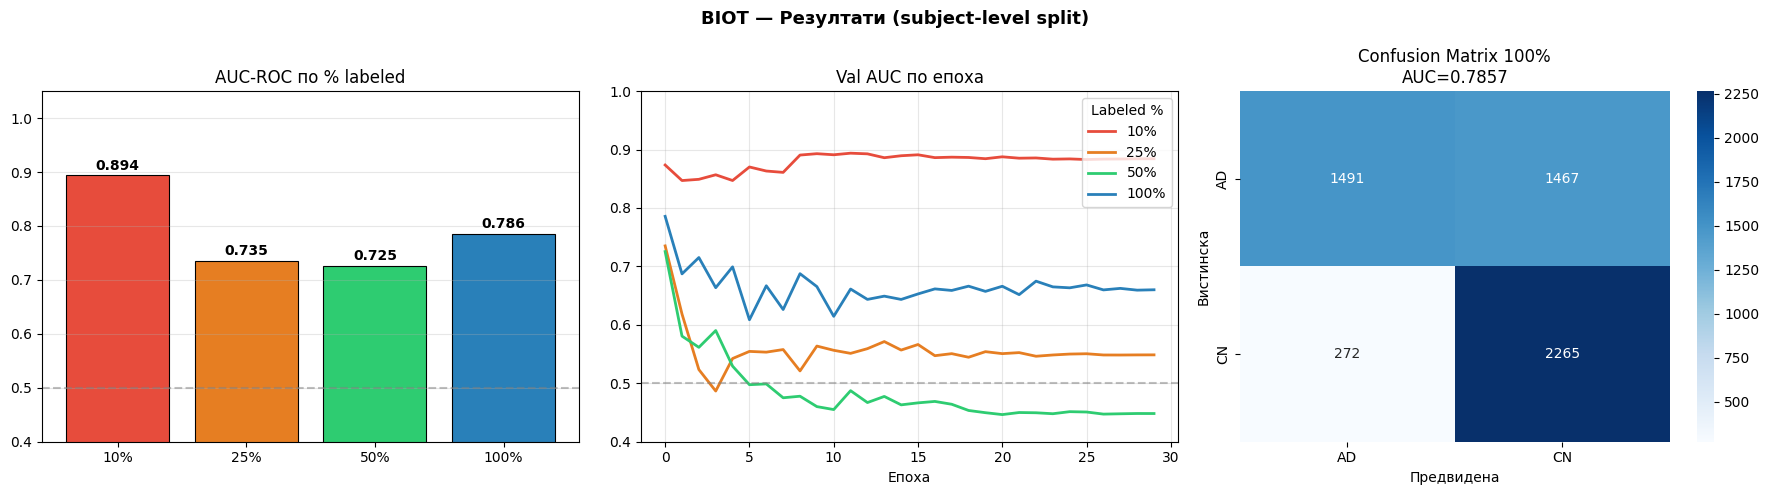

In [ ]:
COLORS = {0.10: '#e74c3c', 0.25: '#e67e22', 0.50: '#2ecc71', 1.00: '#2980b9'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BIOT — Резултати (subject-level split)', fontsize=13, fontweight='bold')

biot_auc = [biot_results[f]['auc'] for f in FRACTIONS]
axes[0].bar([f'{int(f*100)}%' for f in FRACTIONS], biot_auc,
            color=[COLORS[f] for f in FRACTIONS], edgecolor='black', linewidth=0.8)
for i, v in enumerate(biot_auc):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('AUC-ROC по % labeled')
axes[0].set_ylim(0.4, 1.05); axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3, axis='y')


for frac, res in biot_results.items():
    axes[1].plot(res['history']['val_auc'], color=COLORS[frac], label=f'{int(frac*100)}%', lw=2)
axes[1].set_title('Val AUC по епоха')
axes[1].set_xlabel('Епоха'); axes[1].set_ylim(0.4, 1.0)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].legend(title='Labeled %'); axes[1].grid(True, alpha=0.3)

# Confusion Matrix 100%
cm = confusion_matrix(biot_results[1.0]['labels'], biot_results[1.0]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['AD','CN'], yticklabels=['AD','CN'])
axes[2].set_title(f'Confusion Matrix 100%\nAUC={biot_results[1.0]["auc"]:.4f}')
axes[2].set_ylabel('Вистинска'); axes[2].set_xlabel('Предвидена')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'biot_results.png', dpi=150)
plt.show()


In [ ]:
print('=== Classification Report — BIOT 100% ===')
print(classification_report(
    biot_results[1.0]['labels'],
    biot_results[1.0]['preds'],
    target_names=['AD', 'CN']
))


=== Classification Report — BIOT 100% ===
              precision    recall  f1-score   support

          AD       0.85      0.50      0.63      2958
          CN       0.61      0.89      0.72      2537

    accuracy                           0.68      5495
   macro avg       0.73      0.70      0.68      5495
weighted avg       0.74      0.68      0.67      5495



## 7. Финална споредба — EEGNet vs LaBraM+LoRA vs BIOT

In [ ]:
path = SAVE_DIR + 'labram_results.pkl'

with open(path, 'rb') as f:
    data = f.read()

print(len(data))

0


In [ ]:
def load_pickle_file(path):
    if os.path.isdir(path):
        raise IsADirectoryError(
            f'{path} е папка, не .pkl фајл. Користи целосна патека, на пример: {path.rstrip(os.sep)}_results.pkl'
        )
    with open(path, 'rb') as f:
        return pickle.load(f)

eegnet_results = load_pickle_file(SAVE_DIR + 'eegnet_results.pkl')
labram_results = load_pickle_file(SAVE_DIR + 'labram_results.pkl')
biot_results   = load_pickle_file(SAVE_DIR + 'biot_results.pkl')

print('Резултатите вчитани.')


Резултатите вчитани.


In [ ]:
FRACTIONS   = [0.1, 0.25, 0.5, 1.0]
FRAC_LABELS = ['10%', '25%', '50%', '100%']

MODELS = {
    'EEGNet': {'results': eegnet_results, 'color': '#1D9E75', 'marker': 'o', 'ls': '-'},
    'LaBraM': {'results': labram_results, 'color': '#534AB7', 'marker': 's', 'ls': '--'},
    'BIOT'  : {'results': biot_results,   'color': '#2980b9', 'marker': '^', 'ls': '-.'},
}


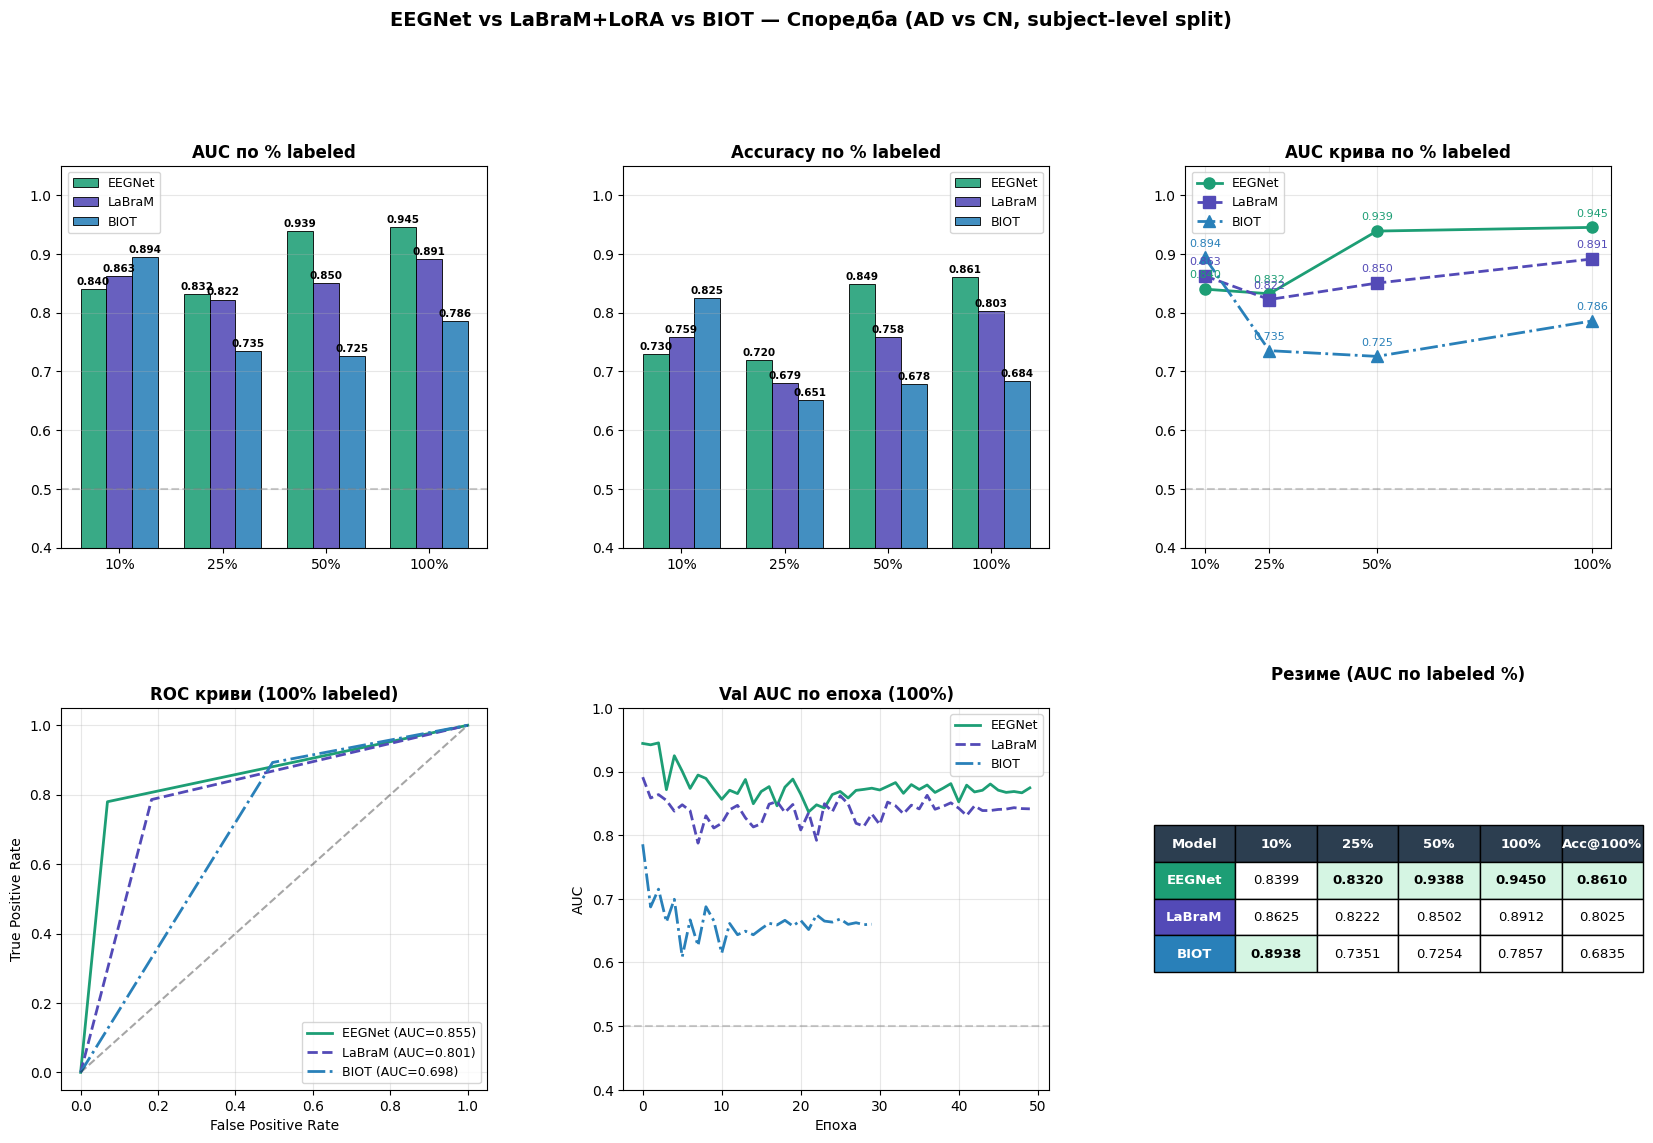

Графиконот зачуван!


In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

ax1   = fig.add_subplot(gs[0, 0])
x     = np.arange(len(FRACTIONS))
width = 0.25
for i, (name, m) in enumerate(MODELS.items()):
    aucs = [m['results'][f]['auc'] for f in FRACTIONS]
    bars = ax1.bar(x + (i-1)*width, aucs, width, label=name,
                   color=m['color'], edgecolor='black', linewidth=0.7, alpha=0.88)
    for bar, val in zip(bars, aucs):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax1.set_title('AUC по % labeled', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(FRAC_LABELS)
ax1.set_ylim(0.4, 1.05); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3, axis='y')


ax2 = fig.add_subplot(gs[0, 1])
for i, (name, m) in enumerate(MODELS.items()):
    accs = [m['results'][f]['acc'] for f in FRACTIONS]
    bars = ax2.bar(x + (i-1)*width, accs, width, label=name,
                   color=m['color'], edgecolor='black', linewidth=0.7, alpha=0.88)
    for bar, val in zip(bars, accs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax2.set_title('Accuracy по % labeled', fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(FRAC_LABELS)
ax2.set_ylim(0.4, 1.05); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis='y')


ax3 = fig.add_subplot(gs[0, 2])
frac_pct = [int(f*100) for f in FRACTIONS]
for name, m in MODELS.items():
    aucs = [m['results'][f]['auc'] for f in FRACTIONS]
    ax3.plot(frac_pct, aucs, color=m['color'], linestyle=m['ls'],
             marker=m['marker'], linewidth=2, markersize=8, label=name)
    for xp, yp in zip(frac_pct, aucs):
        ax3.annotate(f'{yp:.3f}', (xp, yp), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8, color=m['color'])
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax3.set_title('AUC крива по % labeled', fontweight='bold')
ax3.set_xticks(frac_pct); ax3.set_xticklabels(FRAC_LABELS)
ax3.set_ylim(0.4, 1.05); ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)


ax4 = fig.add_subplot(gs[1, 0])
for name, m in MODELS.items():
    res    = m['results'][1.0]
    labels = np.array(res['labels'])

    if 'probs' in res:
        scores = np.array(res['probs'])
    else:
        scores = np.array(res['preds'], dtype=float)
    if len(set(labels)) < 2:
        continue
    fpr, tpr, _ = roc_curve(labels, scores)
    ax4.plot(fpr, tpr, color=m['color'], linestyle=m['ls'],
             linewidth=2, label=f"{name} (AUC={roc_auc_score(labels, scores):.3f})")
ax4.plot([0,1],[0,1],'k--', alpha=0.35)
ax4.set_title('ROC криви (100% labeled)', fontweight='bold')
ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
ax4.legend(loc='lower right', fontsize=9); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
for name, m in MODELS.items():
    hist = m['results'][1.0].get('history')
    if hist is None:
        continue
    key = 'val_auc'
    if key in hist:
        ax5.plot(hist[key], color=m['color'], linestyle=m['ls'], linewidth=2, label=name)
ax5.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax5.set_title('Val AUC по епоха (100%)', fontweight='bold')
ax5.set_xlabel('Епоха'); ax5.set_ylabel('AUC')
ax5.set_ylim(0.4, 1.0); ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
col_labels = ['Model', '10%', '25%', '50%', '100%', 'Acc@100%']
rows = []
for name, m in MODELS.items():
    row = [name]
    for f in FRACTIONS:
        row.append(f"{m['results'][f]['auc']:.4f}")
    row.append(f"{m['results'][1.0]['acc']:.4f}")
    rows.append(row)
table = ax6.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1.15, 2.2)
row_colors = ['#1D9E75', '#534AB7', '#2980b9']
for j in range(len(col_labels)):
    table[0,j].set_facecolor('#2c3e50')
    table[0,j].set_text_props(color='white', fontweight='bold')
for i, color in enumerate(row_colors):
    table[i+1,0].set_facecolor(color)
    table[i+1,0].set_text_props(color='white', fontweight='bold')
for col_idx in range(1, len(col_labels)):
    vals = [float(rows[r][col_idx]) for r in range(len(rows))]
    best = max(vals)
    for r in range(len(rows)):
        if float(rows[r][col_idx]) == best:
            table[r+1,col_idx].set_facecolor('#d5f5e3')
            table[r+1,col_idx].set_text_props(fontweight='bold')
ax6.set_title('Резиме (AUC по labeled %)', fontweight='bold', pad=20)

plt.suptitle('EEGNet vs LaBraM+LoRA vs BIOT — Споредба (AD vs CN, subject-level split)',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig(SAVE_DIR + 'model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Графиконот зачуван!')


In [ ]:
print('=' * 65)
print('ФИНАЛНА СПОРЕДБА — Subject-level split, ADFTD датасет')
print('=' * 65)
print(f"{'Model':>10} {'Labeled':>8} {'AUC':>8} {'Accuracy':>10}")
print('-' * 65)
for name, m in MODELS.items():
    for f in FRACTIONS:
        res = m['results'][f]
        print(f"{name:>10} {int(f*100):>7}% {res['auc']:>8.4f} {res['acc']:>10.4f}")
    print()


ФИНАЛНА СПОРЕДБА — Subject-level split, ADFTD датасет
     Model  Labeled      AUC   Accuracy
-----------------------------------------------------------------
    EEGNet      10%   0.8399     0.7301
    EEGNet      25%   0.8320     0.7197
    EEGNet      50%   0.9388     0.8490
    EEGNet     100%   0.9450     0.8610

    LaBraM      10%   0.8625     0.7587
    LaBraM      25%   0.8222     0.6793
    LaBraM      50%   0.8502     0.7580
    LaBraM     100%   0.8912     0.8025

      BIOT      10%   0.8938     0.8246
      BIOT      25%   0.7351     0.6508
      BIOT      50%   0.7254     0.6777
      BIOT     100%   0.7857     0.6835

